In [ ]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

nutrients = csv.reader(open('e1_nutrients.csv', 'r'))
list_nutrients = list(nutrients)
filter_nutrients = list_nutrients 
'''[1::]'''
set = 1

In [ ]:
class readNutrients:
    def __init__(self, row):
        self.depth = int(row[0])
        self.no2    = float(row[1])
        self.no3no2 = float(row[2])
        self.nh3 = float(row[3])
        self.sio = float(row[4])
        self.po4 = float(row[5])
        
    def __repr__(self):
        return f"Row({self.depth}, {self.no2}, {self.no3no2}, {self.nh3}, {self.sio}, {self.po4})"

In [ ]:
df = pd.DataFrame(filter_nutrients)
depth = df['Depth']

def filterOutlier(depth, row):
    nutrients = depth[row]
    q3 = nutrients.quantile(0.75)
    q1 = nutrients.quantile(0.25)
    iqr = q3 - q1
    lBound = q1 - 1.5 * iqr
    uBound = q3 + 1.5 * iqr
    
    for depth, val in enumerate(nutrients):
        if val > uBound or val < lBound:
            nutrients.iloc[depth] = None
    
    global reducedList
    global preparedList

    reducedList = [i for i in depth[row] if ((i > lBound) & (i < uBound))]
    preparedList = depth.loc[depth.loc]
    


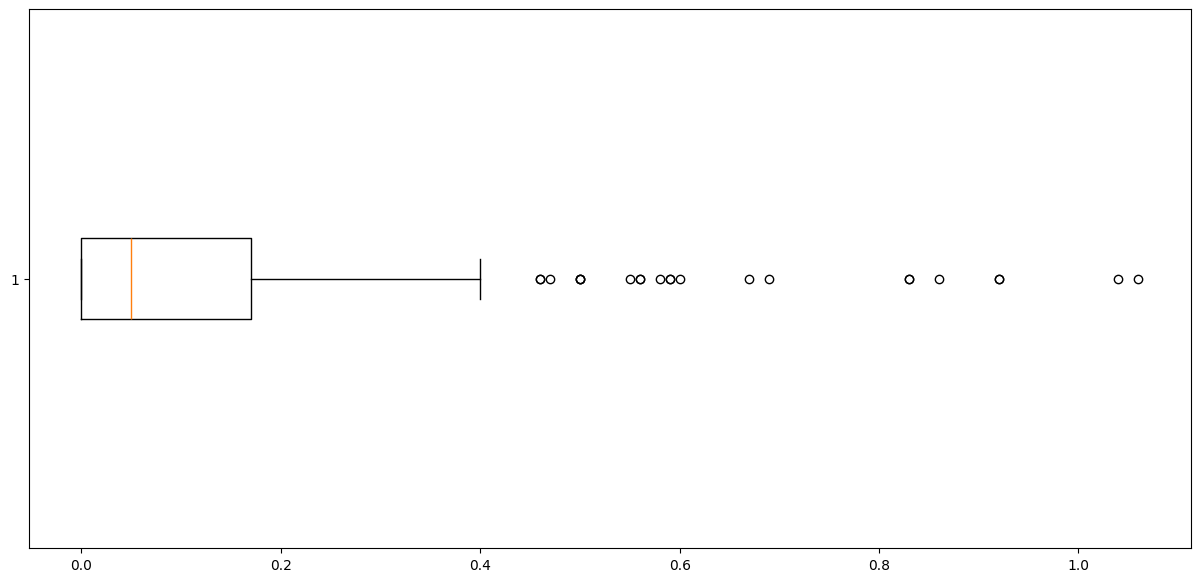

In [ ]:
rows = [readNutrients(row) for row in filter_nutrients]

depthNull = [row for row in rows if row.depth == 0]
plt.figure(figsize=(15, 7))
plt.boxplot([row.no2 for row in depthNull], vert=False)
plt.show()

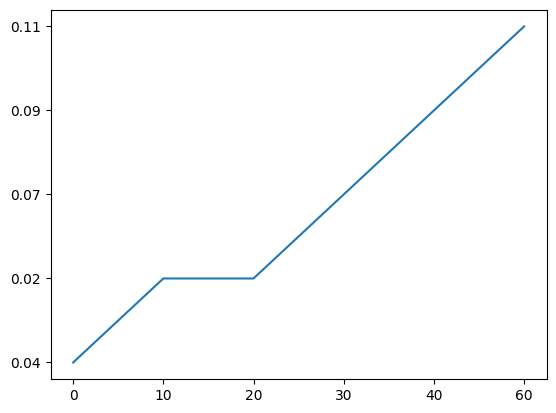

In [ ]:
x,y = zip(*[(row[0], row[1]) for row in filter_nutrients[set*6:set*6+6:]])
plt.plot(x,y)
plt.show()